## Pre-processing Objectives:
1. Create a measure for recidivism in the entire dataset: try various approaches to this as different columns
2. Check the distribution of missing values across states
3. Clean up missing values specific to states chosen

In [3]:
import warnings

# warnings.filterwarnings('ignore')

import pandas as pd

pd.set_option("mode.copy_on_write", True)

/var/folders/rq/6gkwkw8n79d9pw5r3y76nfqc0000gn/T/ipykernel_98402/467590385.py:7: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.set_option("mode.copy_on_write", True)


In [5]:
# load data
import os
import gdown

file_id = "1jkBkjOsdr-0hhUgj3p2J7pk1Welkk7A1"

# check if a csv was already created earlier and download only if it wasn't
if not os.path.exists("dataset.csv"):
    gdown.download(id=file_id, output="dataset.csv", quiet=False)

df = pd.read_csv("dataset.csv", sep="\t")
df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1jkBkjOsdr-0hhUgj3p2J7pk1Welkk7A1
From (redirected): https://drive.google.com/uc?id=1jkBkjOsdr-0hhUgj3p2J7pk1Welkk7A1&confirm=t&uuid=0cec01e4-9c61-4c4f-9142-e9618766e564
To: /Users/teatafaj/Documents/UDS/Recidivism-Education/dataset.csv
100%|██████████| 976M/976M [00:34<00:00, 28.4MB/s] 


,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE
0,A012021000000090128,1,1,2,9,2013,2013,9999,9999,9999,4,8,1,5,5,0,3,1
1,A012021000000110168,1,1,1,9,2004,9999,9999,9999,9999,4,3,1,5,9,9,9,1
2,A012021000000090187,1,1,2,9,2009,2009,9999,9999,9999,0,11,9,1,1,0,1,1
3,A012021000000010425,1,3,3,9,2016,2016,9999,9999,9999,2,12,9,3,3,0,3,1
4,A012021000000090117,1,1,1,9,2009,2017,9999,9999,9999,4,4,9,1,2,3,1,1


In [6]:
df = df.drop_duplicates()
df.shape

(13768054, 18)

In [7]:
# df = df.drop(df["ADMITYR"] == None)
df["ADMITYR"].value_counts()

ADMITYR
2008    640278
2009    638225
2007    624535
2010    616765
2006    610434
         ...  
1952        29
1953        21
1951        21
1955        20
1950        16
Name: count, Length: 72, dtype: int64

In [8]:
# add state names
state_map = {
    1: "Alabama",
    2: "Alaska",
    4: "Arizona",
    5: "Arkansas",
    6: "California",
    8: "Colorado",
    9: "Connecticut",
    10: "Delaware",
    11: "District of Columbia",
    12: "Florida",
    13: "Georgia",
    15: "Hawaii",
    16: "Idaho",
    17: "Illinois",
    18: "Indiana",
    19: "Iowa",
    20: "Kansas",
    21: "Kentucky",
    22: "Louisiana",
    23: "Maine",
    24: "Maryland",
    25: "Massachusetts",
    26: "Michigan",
    27: "Minnesota",
    28: "Mississippi",
    29: "Missouri",
    30: "Montana",
    31: "Nebraska",
    32: "Nevada",
    33: "New Hampshire",
    34: "New Jersey",
    35: "New Mexico",
    36: "New York",
    37: "North Carolina",
    38: "North Dakota",
    39: "Ohio",
    40: "Oklahoma",
    41: "Oregon",
    42: "Pennsylvania",
    44: "Rhode Island",
    45: "South Carolina",
    46: "South Dakota",
    47: "Tennessee",
    48: "Texas",
    49: "Utah",
    50: "Vermont",
    51: "Virginia",
    53: "Washington",
    54: "West Virginia",
    55: "Wisconsin",
}

df["STATE_NAME"] = df["STATE"].map(state_map)

# Verify
print(df["STATE_NAME"].unique())

<StringArray>
[             'Alabama',              'Arizona',           'California',
             'Colorado',             'Delaware',              'Florida',
              'Georgia',             'Illinois',              'Indiana',
                 'Iowa',               'Kansas',             'Kentucky',
            'Louisiana',                'Maine',             'Maryland',
        'Massachusetts',             'Michigan',            'Minnesota',
          'Mississippi',             'Missouri',              'Montana',
             'Nebraska',               'Nevada',        'New Hampshire',
           'New Jersey',           'New Mexico',             'New York',
       'North Carolina',         'North Dakota',                 'Ohio',
             'Oklahoma',               'Oregon',         'Pennsylvania',
         'Rhode Island',       'South Carolina',         'South Dakota',
            'Tennessee',                'Texas',                 'Utah',
           'Washington',        'West

1. Create a measure for recidivism in the entire dataset: try various approaches to this as different columns

In [9]:
df["tot_arrest_counts"] = df.groupby("ABT_INMATE_ID")["ABT_INMATE_ID"].transform(
    "count"
)
df

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE,STATE_NAME,tot_arrest_counts
0,A012021000000090128,1,1,2,9,2013,2013,9999,9999,9999,4,8,1,5,5,0,3,1,Alabama,1
1,A012021000000110168,1,1,1,9,2004,9999,9999,9999,9999,4,3,1,5,9,9,9,1,Alabama,1
2,A012021000000090187,1,1,2,9,2009,2009,9999,9999,9999,0,11,9,1,1,0,1,1,Alabama,1
3,A012021000000010425,1,3,3,9,2016,2016,9999,9999,9999,2,12,9,3,3,0,3,1,Alabama,4
4,A012021000000090117,1,1,1,9,2009,2017,9999,9999,9999,4,4,9,1,2,3,1,1,Alabama,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13897851,A112020000001771624,1,1,3,9,2007,2010,2011,2010,9999,2,12,2,9,9,2,1,11,District of Columbia,1
13897852,A112020000001771626,1,1,1,9,2001,2004,2004,2004,9999,3,4,2,9,9,2,1,11,District of Columbia,2
13897853,A112020000001771626,1,1,1,9,2007,2013,2017,2017,9999,4,4,2,9,9,3,1,11,District of Columbia,2
13897854,A112020000001771666,1,1,1,9,2010,2014,2014,2013,9999,2,1,2,9,9,2,1,11,District of Columbia,2


In [10]:
# Step 1: Get the latest release year per inmate per year
latest_release = (
    df.groupby(["ABT_INMATE_ID", "ADMITYR"])["RELEASEYR"]
    .max()
    .reset_index()
    .rename(columns={"RELEASEYR": "LATEST_RELEASEYR"})
)

# Step 2: Get unique inmate-year combinations for future appearances
future_appearances = df[["ABT_INMATE_ID", "ADMITYR"]].drop_duplicates()

# Step 3: Self-merge to compare each inmate's latest release year against future admissions
merged = latest_release.merge(
    future_appearances, on="ABT_INMATE_ID", suffixes=("", "_FUTURE")
)

# Step 4: Check if future admission falls within 2 years after latest release
recid_flag = (
    merged[
        (merged["ADMITYR_FUTURE"] > merged["LATEST_RELEASEYR"])
        & (merged["ADMITYR_FUTURE"] <= merged["LATEST_RELEASEYR"] + 2)
    ][["ABT_INMATE_ID", "ADMITYR"]]
    .drop_duplicates()
    .assign(within_2_yrs=1)
)

# Step 5: Merge back and fill non-recidivists with 0
df = df.merge(recid_flag, on=["ABT_INMATE_ID", "ADMITYR"], how="left")
df["within_2_yrs"] = df["within_2_yrs"].fillna(0).astype(int)

In [11]:
df

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,...,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE,STATE_NAME,tot_arrest_counts,within_2_yrs
0,A012021000000090128,1,1,2,9,2013,2013,9999,9999,9999,...,8,1,5,5,0,3,1,Alabama,1,0
1,A012021000000110168,1,1,1,9,2004,9999,9999,9999,9999,...,3,1,5,9,9,9,1,Alabama,1,0
2,A012021000000090187,1,1,2,9,2009,2009,9999,9999,9999,...,11,9,1,1,0,1,1,Alabama,1,0
3,A012021000000010425,1,3,3,9,2016,2016,9999,9999,9999,...,12,9,3,3,0,3,1,Alabama,4,1
4,A012021000000090117,1,1,1,9,2009,2017,9999,9999,9999,...,4,9,1,2,3,1,1,Alabama,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13768049,A112020000001771624,1,1,3,9,2007,2010,2011,2010,9999,...,12,2,9,9,2,1,11,District of Columbia,1,0
13768050,A112020000001771626,1,1,1,9,2001,2004,2004,2004,9999,...,4,2,9,9,2,1,11,District of Columbia,2,0
13768051,A112020000001771626,1,1,1,9,2007,2013,2017,2017,9999,...,4,2,9,9,3,1,11,District of Columbia,2,0
13768052,A112020000001771666,1,1,1,9,2010,2014,2014,2013,9999,...,1,2,9,9,2,1,11,District of Columbia,2,1


2. Check the distribution of missing values across states

3. Clean up missing values specific to states chosen

In [15]:
df = df[df["RELEASEYR"] != 9999]

In [16]:
df["RELEASEYR"].describe()

count    1.277159e+07
mean     2.007781e+03
std      8.036886e+00
min      1.971000e+03
25%      2.003000e+03
50%      2.009000e+03
75%      2.014000e+03
max      2.020000e+03
Name: RELEASEYR, dtype: float64

# Exploring potential data errors

In [19]:
(df["ADMITYR"] > df["RELEASEYR"]).sum()

np.int64(346)

In [20]:
df[df["ADMITYR"] > df["RELEASEYR"]].head(20)

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,...,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE,STATE_NAME,tot_arrest_counts,within_2_yrs
1271,A012021000000062444,1,2,3,9,9999,2017,9999,9999,9999,...,12,1,1,3,4,1,1,Alabama,2,1
138681,A012021000000042290,2,1,3,9,9999,2020,9999,9999,9999,...,12,1,1,3,4,9,1,Alabama,2,0
1009196,A062021000000830057,1,1,2,9,9999,1993,9999,9999,9999,...,7,1,1,5,4,3,6,California,1,0
1770719,A062021000001043824,1,1,2,9,9999,1993,9999,9999,9999,...,7,1,2,5,4,3,6,California,1,0
2021848,A062021000001272319,1,1,1,9,9999,1999,9999,9999,9999,...,5,1,2,5,4,9,6,California,1,0
3647884,A122021000000038925,1,2,1,9,9999,2006,2017,2006,2003,...,4,2,1,4,4,1,12,Florida,1,0
3879576,A122021000000073756,1,2,1,9,9999,2019,4147,9999,2075,...,3,2,1,5,4,3,12,Florida,1,0
4453026,A132021000000700906,1,1,2,9,9999,1976,1973,9999,9999,...,10,2,9,9,4,3,13,Georgia,1,0
4453860,A132021000000629494,1,1,2,9,9999,1971,9999,9999,9999,...,7,2,2,5,4,1,13,Georgia,1,0
4458375,A132021000000813620,1,1,1,9,9999,2009,9999,9999,9999,...,1,2,1,5,4,3,13,Georgia,1,0


In [21]:
df[df["ADMITYR"] > df["RELEASEYR"]]["STATE_NAME"].value_counts()

STATE_NAME
Georgia          259
Minnesota         49
New Hampshire     17
Michigan           4
California         3
Alabama            2
Florida            2
Illinois           2
Nebraska           2
West Virginia      2
New Jersey         1
Ohio               1
Pennsylvania       1
Rhode Island       1
Name: count, dtype: int64

Some cases are noted where the Admit year is missing and noted as 9999. mostly seemingly from Georgia. FIltering out the observations below.

In [22]:
df = df[df["ADMITYR"] != 9999]

In [23]:
(df["ADMITYR"] > df["RELEASEYR"]).sum()

np.int64(0)

# Convert missing data from 9 to Nan

In [27]:
df[["RACE", "AGEADMIT", "AGERELEASE", "OFFDETAIL", "RELTYPE", "TIMESRVD"]].nunique()

RACE           4
AGEADMIT       5
AGERELEASE     6
OFFDETAIL     14
RELTYPE        4
TIMESRVD       5
dtype: int64

In [37]:
import numpy as np

df["RACE"] = df["RACE"].replace(9, np.nan)
df["AGEADMIT"] = df["AGEADMIT"].replace(9, np.nan)
df["OFFDETAIL"] = df["OFFDETAIL"].replace(99, np.nan)
df["SENTLGTH"] = df["SENTLGTH"].replace(9, np.nan)
df["RELTYPE"] = df["RELTYPE"].replace(9, np.nan)

In [38]:
import pandas as pd

# percentage of missing values by column
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

# convert to dataframe for nicer display
missing_table = missing_pct.reset_index()
missing_table.columns = ["Variable", "Percent_NaN"]

# show only columns with at least some missing values
missing_table = missing_table[missing_table["Percent_NaN"] > 0]

print(missing_table.to_string(index=False))

  Variable  Percent_NaN
      RACE     9.381171
   RELTYPE     5.032870
  SENTLGTH     0.577015
 OFFDETAIL     0.495206
  AGEADMIT     0.370880
STATE_NAME     0.104923


For the most part, Nan values are negligble. Race presents somewhat of an issue and might require caution if used later in analysis

# Checking Observations per State

In [39]:
state_counts = df["STATE_NAME"].value_counts()

print(state_counts.to_string())

STATE_NAME
California              2650770
Texas                   1254621
Illinois                 843174
Florida                  760390
Georgia                  714266
New York                 693991
North Carolina           504978
Pennsylvania             477174
Missouri                 418203
Kentucky                 374500
Michigan                 366043
Arizona                  329937
Tennessee                312248
Indiana                  297203
Ohio                     265056
South Carolina           226031
Washington               208010
Colorado                 194178
Wisconsin                189086
New Jersey               186698
Oklahoma                 182596
Alabama                  178587
Mississippi              148391
Minnesota                147773
Louisiana                100768
Iowa                      84048
Delaware                  78479
Nevada                    74048
Utah                      69147
Rhode Island              60274
Kansas                    502

In [40]:
state_year = df.groupby(["STATE_NAME", "RELEASEYR"]).size()

print(state_year.head(20))

STATE_NAME  RELEASEYR
Alabama     2007         12105
            2008         12853
            2009         13449
            2010         13341
            2011         12367
            2012         12442
            2013         12784
            2014         13183
            2015         12607
            2016         12370
            2017         12954
            2018         13830
            2019         13267
            2020         11035
Arizona     2000         11524
            2001         11851
            2002         12941
            2003         14126
            2004         14872
            2005         16372
dtype: int64


In [41]:
state_year_range = df.groupby("STATE_NAME")["RELEASEYR"].agg(["min", "max", "count"])

print(state_year_range.sort_values("count", ascending=False).to_string())

                       min   max    count
STATE_NAME                               
California            1992  2020  2650770
Texas                 2005  2020  1254621
Illinois              1989  2020   843174
Florida               1996  2020   760390
Georgia               1971  2020   714266
New York              1994  2020   693991
North Carolina        1999  2020   504978
Pennsylvania          1990  2020   477174
Missouri              1998  2020   418203
Kentucky              1989  2020   374500
Michigan              1989  2018   366043
Arizona               2000  2018   329937
Tennessee             2000  2020   312248
Indiana               2002  2020   297203
Ohio                  2009  2020   265056
South Carolina        2000  2020   226031
Washington            1989  2020   208010
Colorado              2000  2020   194178
Wisconsin             2000  2020   189086
New Jersey            2003  2018   186698
Oklahoma              2000  2020   182596
Alabama               2007  2020  

In [42]:
df["RELEASEYR"].value_counts().sort_index()

RELEASEYR
1971      3583
1972      5396
1973      5219
1974      5880
1975      6307
1976      6038
1977      6670
1978      7349
1979      6178
1980      7932
1981      8035
1982      8856
1983     10942
1984     11511
1985     11974
1986     12721
1987     14201
1988     13192
1989     42604
1990     59321
1991     62225
1992    145096
1993    147852
1994    191409
1995    203345
1996    236487
1997    248333
1998    264348
1999    294133
2000    361306
2001    374138
2002    389094
2003    416673
2004    443629
2005    532615
2006    561067
2007    587769
2008    601026
2009    632177
2010    614120
2011    598589
2012    540513
2013    529151
2014    528677
2015    532556
2016    523378
2017    528394
2018    522555
2019    478507
2020    428170
Name: count, dtype: int64

# Policy Adoptions


Several different policies are adopted throughout history, with some minor changes happening in the recent years - the latter more than not are facility related rather than statewide. In the interest of a DiD analysis we explore two different information sets:

1. Adoption of Second Chance Pell Experimental Sites - the adoption was through colleges, and for the purpose of our analysis we will outline the states with the largest numbers of facilities and students ellibigle.

2. Snaposhot view of Policy adoption across the three pillars (automatic enrollment, central administration, incentives) and availbaility of education in states, referenced by a 24' study.

In [52]:
df["PELL_2016"] = df["STATE_NAME"].map(pell_2016)

In [53]:
pell_2016 = {
    "Alabama": 1,
    "Arizona": 0,
    "California": 1,
    "Colorado": 0,
    "Delaware": 0,
    "Florida": 1,
    "Georgia": 0,
    "Illinois": 1,
    "Indiana": 1,
    "Iowa": 1,
    "Kansas": 0,
    "Kentucky": 0,
    "Louisiana": 0,
    "Maine": 1,
    "Maryland": 1,
    "Massachusetts": 1,
    "Michigan": 1,
    "Minnesota": 1,
    "Mississippi": 0,
    "Missouri": 0,
    "Montana": 0,
    "Nebraska": 1,
    "Nevada": 0,
    "New Hampshire": 0,
    "New Jersey": 1,
    "New Mexico": 0,
    "New York": 1,
    "North Carolina": 0,
    "North Dakota": 0,
    "Ohio": 1,
    "Oklahoma": 1,
    "Oregon": 1,
    "Pennsylvania": 1,
    "Rhode Island": 0,
    "South Carolina": 1,
    "South Dakota": 0,
    "Tennessee": 0,
    "Texas": 1,
    "Utah": 0,
    "Washington": 1,
    "West Virginia": 1,
    "Wisconsin": 1,
    "District of Columbia": 0,
}

In [78]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# restrict to pre-treatment period
df_pre = df[(df["RELEASEYR"] >= 2000) & (df["RELEASEYR"] < 2016)]

# compute average recidivism by state-year
state_trends = (
    df_pre.groupby(["STATE_NAME", "RELEASEYR"])["within_2_yrs"].mean().reset_index()
)

In [79]:
tx = state_trends[state_trends["STATE_NAME"] == "Texas"]

X = tx["RELEASEYR"].values.reshape(-1, 1)
y = tx["within_2_yrs"].values

tx_model = LinearRegression().fit(X, y)
tx_slope = tx_model.coef_[0]

In [80]:
scores = []

for state in state_trends["STATE_NAME"].unique():

    if state == "Texas":
        continue

    temp = state_trends[state_trends["STATE_NAME"] == state]

    if len(temp) < 5:
        continue

    X = temp["RELEASEYR"].values.reshape(-1, 1)
    y = temp["within_2_yrs"].values

    model = LinearRegression().fit(X, y)
    slope = model.coef_[0]

    diff = abs(slope - tx_slope)

    scores.append((state, diff))

scores = pd.DataFrame(scores, columns=["state", "slope_diff"])
scores.sort_values("slope_diff").head(10)

,state,slope_diff
32,Tennessee,0.000221
25,North Carolina,0.000525
1,Arizona,0.001053
9,Indiana,0.001054
7,Georgia,0.001079
36,Wisconsin,0.001162
17,Missouri,0.001504
30,Rhode Island,0.001758
6,Florida,0.002004
4,Delaware,0.002033


<Axes: xlabel='RELEASEYR'>

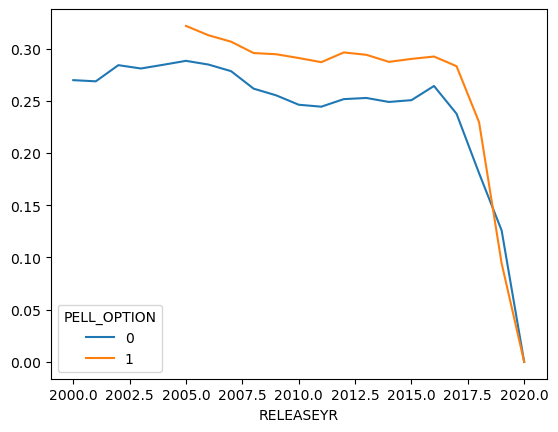

In [81]:
states_option_try = [
    "Texas",
    "Tennessee",
    "North Carolina",
    "Arizona",
    "Indiana",
    "Georgia",
]

df_large = df[
    (df["STATE_NAME"].isin(states_option_try)) & (df["RELEASEYR"] >= 2000)
].copy()

treated_states = ["Texas"]

df_large["PELL_OPTION"] = df_large["STATE_NAME"].isin(treated_states).astype(int)

df_large.groupby(["RELEASEYR", "PELL_OPTION"])["within_2_yrs"].mean().unstack().plot()